# Monte Carlo Tree Search for Tic-Tac-Toe

This notebook demonstrates **Monte Carlo Tree Search (MCTS)** on Tic-Tac-Toe.

The focus is on understanding the complete search process:

1. Selection
2. Expansion
3. Simulation
4. Backpropagation
5. Final action selection

Every numerical value shown in the demonstrations is generated by the code from the Tic-Tac-Toe game model and the MCTS search statistics.

---

## 1. Problem Definition

Tic-Tac-Toe is a two-player, deterministic, zero-sum game played on a $3\times3$ grid.

Player `X` moves first. The players alternate placing their symbol in an empty cell.

A player wins by placing three identical symbols in:

- one row,
- one column,
- or one diagonal.

If all cells are filled and neither player has three in a row, the game ends in a draw.

### Board indexing

```text
0 | 1 | 2
---------
3 | 4 | 5
---------
6 | 7 | 8
```

### State

A state $s$ is the complete board configuration together with the player whose turn it is.

The board is encoded as:

- $1$ = `X`
- $-1$ = `O`
- $0$ = empty

For example,

```text
X | O | X
---------
  | O |
---------
  |   |
```

is represented as

```python
(1, -1, 1,
 0, -1, 0,
 0,  0, 0)
```

### Action

An action $a$ is the index of an empty cell.

If cells $3,5,6,7,8$ are empty, then

$$
\mathcal{A}(s)=\{3,5,6,7,8\}.
$$

### Transition

The transition is deterministic.

If player $p$ selects an empty cell $a$, the next state $s'$ is obtained by placing $p$ in that cell.

Therefore,

$$
P(s'|s,a)=1
$$

for the board produced by the legal move, and $0$ for all other states.

### Reward

The search uses terminal game outcomes.

From the perspective of the player who made the move leading into a node:

$$
R=
\begin{cases}
+1, & \text{win}\\
0, & \text{draw}\\
-1, & \text{loss}
\end{cases}
$$

### What MCTS learns during search

MCTS does **not** train a parameterized model such as a neural network.

Instead, repeated simulations build search statistics for state-action choices:

- visit count $N(s,a)$,
- accumulated return $W(s,a)$,
- mean return $\bar Q(s,a)$.

The mean return is

$$
\bar Q(s,a)
=
\frac{W(s,a)}{N(s,a)}.
$$

As more simulations are performed, promising actions receive more evidence.

The final move is selected from the search-tree statistics.

# 2. Monte Carlo Tree Search Algorithm

One complete MCTS iteration has four main stages.

```text
Current state
     ↓
1. Selection
     ↓
2. Expansion
     ↓
3. Simulation
     ↓
4. Backpropagation
     ↓
Update tree statistics
```

After many iterations, the action with the strongest search evidence is selected.

---

## Step 1 — Selection

Starting at the root, repeatedly choose a promising child until reaching a node that is terminal or not fully expanded.

This notebook uses the UCT rule:

$$
\text{UCT}(s,a)
=
\bar Q(s,a)
+
c
\sqrt{
\frac{\ln N(s)}
{N(s,a)}
}.
$$

The selected action is

$$
a^*
=
\arg\max_a
\text{UCT}(s,a).
$$

The two terms have different roles.

### Exploitation term

$$
\bar Q(s,a)
$$

favors actions that have produced strong returns.

### Exploration term

$$
c
\sqrt{
\frac{\ln N(s)}
{N(s,a)}
}
$$

favors actions that have been explored less often.

The constant $c$ controls the exploration strength.

---

## Step 2 — Expansion

If the selected node has an untried legal action, one untried action is chosen and a new child node is added to the tree.

---

## Step 3 — Simulation

From the newly expanded node, the game is played to a terminal state using a rollout policy.

This notebook uses random legal moves during rollout.

The simulation ends with:

$$
G\in\{-1,0,+1\}.
$$

---

## Step 4 — Backpropagation

The simulation result is propagated back through every node on the selected path.

For each visited node:

$$
N \leftarrow N+1
$$

and

$$
W \leftarrow W+G.
$$

The updated mean value is

$$
\bar Q
=
\frac{W}{N}.
$$

Because Tic-Tac-Toe is a two-player zero-sum game, the outcome is interpreted from the perspective of the player who made the move leading into each child node.

---

## Final move

After the search budget is exhausted, this implementation chooses the root action with the largest visit count:

$$
a^*
=
\arg\max_a N(s,a).
$$

Using visit count for the final decision is common because it reflects how strongly the search concentrated on each move.

## 3. Imports

In [1]:
import math
import random
from dataclasses import dataclass, field

import matplotlib.pyplot as plt
import numpy as np

## 4. Tic-Tac-Toe game model

In [2]:
EMPTY = 0
X = 1
O = -1

WIN_LINES = [
    (0, 1, 2),
    (3, 4, 5),
    (6, 7, 8),
    (0, 3, 6),
    (1, 4, 7),
    (2, 5, 8),
    (0, 4, 8),
    (2, 4, 6),
]


def player_symbol(player):
    return "X" if player == X else "O"


def winner(board):
    for a, b, c in WIN_LINES:
        line_sum = board[a] + board[b] + board[c]

        if line_sum == 3:
            return X

        if line_sum == -3:
            return O

    if all(cell != EMPTY for cell in board):
        return 0

    return None


def legal_actions(board):
    if winner(board) is not None:
        return []

    return [
        index
        for index, cell in enumerate(board)
        if cell == EMPTY
    ]


def apply_action(board, action, player):
    if action not in legal_actions(board):
        raise ValueError(
            f"Action {action} is not legal."
        )

    new_board = list(board)
    new_board[action] = player

    return tuple(new_board)


def render_board(board, show_indices=False):
    symbols = {
        X: "X",
        O: "O",
        EMPTY: " ",
    }

    cells = []

    for index, value in enumerate(board):
        if (
            value == EMPTY
            and show_indices
        ):
            cells.append(str(index))
        else:
            cells.append(symbols[value])

    return (
        f"{cells[0]} | {cells[1]} | {cells[2]}\n"
        "---------\n"
        f"{cells[3]} | {cells[4]} | {cells[5]}\n"
        "---------\n"
        f"{cells[6]} | {cells[7]} | {cells[8]}"
    )

## 5. Inspect the initial game

In [3]:
initial_board = (
    0, 0, 0,
    0, 0, 0,
    0, 0, 0,
)

print("Initial board:")
print(render_board(initial_board, show_indices=True))

print(
    "\nLegal actions:",
    legal_actions(initial_board),
)

print(
    "Player to move:",
    player_symbol(X),
)

Initial board:
0 | 1 | 2
---------
3 | 4 | 5
---------
6 | 7 | 8

Legal actions: [0, 1, 2, 3, 4, 5, 6, 7, 8]
Player to move: X


The initial state has nine possible actions.

For example, if `X` chooses action $4$, the transition is deterministic.

In [4]:
example_next_state = apply_action(
    initial_board,
    action=4,
    player=X,
)

print("After X chooses action 4:")
print(render_board(example_next_state, show_indices=True))

After X chooses action 4:
0 | 1 | 2
---------
3 | X | 5
---------
6 | 7 | 8


## 6. Search-tree node

In [5]:
@dataclass
class MCTSNode:
    state: tuple
    player_to_move: int
    parent: object = None
    action: object = None
    children: dict = field(
        default_factory=dict
    )
    visits: int = 0
    value_sum: float = 0.0
    untried_actions: list = field(
        default_factory=list
    )

    def __post_init__(self):
        if not self.untried_actions:
            self.untried_actions = (
                legal_actions(
                    self.state
                )
            )

    @property
    def mean_value(self):
        if self.visits == 0:
            return 0.0

        return (
            self.value_sum
            / self.visits
        )

For each child node:

- `visits` stores $N(s,a)$,
- `value_sum` stores $W(s,a)$,
- `mean_value` stores $\bar Q(s,a)$.

## 7. UCT calculation

In [6]:
def uct_score(
    parent_visits,
    child,
    exploration_constant=math.sqrt(2),
):
    if child.visits == 0:
        return float("inf")

    exploitation = (
        child.mean_value
    )

    exploration = (
        exploration_constant
        * math.sqrt(
            math.log(
                parent_visits
            )
            / child.visits
        )
    )

    return (
        exploitation
        + exploration
    )


def select_child_uct(
    node,
    exploration_constant=math.sqrt(2),
):
    scores = {
        action: uct_score(
            node.visits,
            child,
            exploration_constant,
        )
        for action, child
        in node.children.items()
    }

    best_score = max(
        scores.values()
    )

    best_actions = [
        action
        for action, score
        in scores.items()
        if np.isclose(
            score,
            best_score,
        )
    ]

    selected_action = min(
        best_actions
    )

    return (
        selected_action,
        node.children[
            selected_action
        ],
        scores,
    )

# 8. The Four MCTS Steps in Code

The following functions implement Selection, Expansion, Simulation, and Backpropagation separately so each stage can be inspected.

### 8.1 Selection

In [7]:
def selection(
    root,
    exploration_constant=math.sqrt(2),
):
    node = root
    selected_actions = []
    selection_scores = []

    while (
        winner(node.state) is None
        and len(
            node.untried_actions
        ) == 0
    ):
        (
            action,
            child,
            scores,
        ) = select_child_uct(
            node,
            exploration_constant,
        )

        selected_actions.append(
            action
        )

        selection_scores.append(
            scores
        )

        node = child

    return (
        node,
        selected_actions,
        selection_scores,
    )

### 8.2 Expansion

In [8]:
def expansion(
    node,
    rng,
):
    if (
        winner(node.state)
        is not None
    ):
        return node, None

    if not node.untried_actions:
        return node, None

    action = rng.choice(
        node.untried_actions
    )

    node.untried_actions.remove(
        action
    )

    next_board = apply_action(
        node.state,
        action,
        node.player_to_move,
    )

    child = MCTSNode(
        state=next_board,
        player_to_move=(
            -node.player_to_move
        ),
        parent=node,
        action=action,
    )

    node.children[action] = child

    return child, action

### 8.3 Simulation

In [9]:
def simulation(
    state,
    player_to_move,
    rng,
):
    board = state
    player = player_to_move
    rollout_actions = []

    while winner(board) is None:
        action = rng.choice(
            legal_actions(board)
        )

        rollout_actions.append(
            (
                player,
                action,
            )
        )

        board = apply_action(
            board,
            action,
            player,
        )

        player = -player

    return (
        winner(board),
        rollout_actions,
        board,
    )

### 8.4 Backpropagation

In [10]:
def backpropagation(
    node,
    game_outcome,
):
    path_updates = []

    while node is not None:
        node.visits += 1

        # Every child value is stored from
        # the perspective of the player
        # who made the move leading into it.
        if node.parent is not None:
            player_just_moved = (
                -node.player_to_move
            )

            if game_outcome == 0:
                reward = 0.0

            elif (
                game_outcome
                == player_just_moved
            ):
                reward = 1.0

            else:
                reward = -1.0

            node.value_sum += reward

            path_updates.append(
                {
                    "action": node.action,
                    "reward": reward,
                    "visits": node.visits,
                    "value_sum": (
                        node.value_sum
                    ),
                    "mean_value": (
                        node.mean_value
                    ),
                }
            )

        else:
            path_updates.append(
                {
                    "action": "ROOT",
                    "reward": None,
                    "visits": node.visits,
                    "value_sum": (
                        node.value_sum
                    ),
                    "mean_value": (
                        node.mean_value
                    ),
                }
            )

        node = node.parent

    return path_updates

# 9. One Complete MCTS Iteration

The board below is used to make one search iteration easy to inspect.

```text
X | O | X
---------
  | O |
---------
  |   |
```

It is `X`'s turn.

The legal actions are $3,5,6,7,8$.

The code will perform exactly one MCTS iteration and print:

- the selected path,
- the expanded action,
- the rollout moves,
- the terminal result,
- the values updated during backpropagation.

In [11]:
demo_board = (
     1, -1,  1,
     0, -1,  0,
     0,  0,  0,
)

demo_player = X

print(render_board(
    demo_board,
    show_indices=True,
))

print(
    "\nPlayer to move:",
    player_symbol(
        demo_player
    ),
)

print(
    "Legal actions:",
    legal_actions(
        demo_board
    ),
)

X | O | X
---------
3 | O | 5
---------
6 | 7 | 8

Player to move: X
Legal actions: [3, 5, 6, 7, 8]


In [12]:
demo_rng = random.Random(
    7
)

demo_root = MCTSNode(
    state=demo_board,
    player_to_move=demo_player,
)

(
    selected_node,
    selected_actions,
    selected_scores,
) = selection(
    demo_root
)

(
    expanded_node,
    expanded_action,
) = expansion(
    selected_node,
    demo_rng,
)

(
    outcome,
    rollout_actions,
    rollout_final_board,
) = simulation(
    expanded_node.state,
    expanded_node.player_to_move,
    demo_rng,
)

updates = backpropagation(
    expanded_node,
    outcome,
)

print(
    "Selection path:",
    selected_actions,
)

print(
    "Expanded action:",
    expanded_action,
)

print(
    "\nBoard after expansion:"
)

print(
    render_board(
        expanded_node.state,
        show_indices=True,
    )
)

print(
    "\nRollout actions:"
)

for player, action in rollout_actions:
    print(
        player_symbol(player),
        "->",
        action,
    )

print(
    "\nFinal rollout board:"
)

print(
    render_board(
        rollout_final_board
    )
)

outcome_text = (
    "Draw"
    if outcome == 0
    else f"{player_symbol(outcome)} wins"
)

print(
    "\nSimulation outcome:",
    outcome_text,
)

print(
    "\nBackpropagation updates:"
)

for update in updates:
    print(update)

Selection path: []
Expanded action: 6

Board after expansion:
X | O | X
---------
3 | O | 5
---------
X | 7 | 8

Rollout actions:
O -> 5
X -> 7
O -> 3

Final rollout board:
X | O | X
---------
O | O | O
---------
X | X |  

Simulation outcome: O wins

Backpropagation updates:
{'action': 6, 'reward': -1.0, 'visits': 1, 'value_sum': -1.0, 'mean_value': -1.0}
{'action': 'ROOT', 'reward': None, 'visits': 1, 'value_sum': 0.0, 'mean_value': 0.0}


On the first iteration the root has no existing children, so there is no UCT comparison yet.

Selection immediately stops at the root, Expansion creates one child, Simulation produces a complete game, and Backpropagation updates that child and the root.

UCT becomes important after enough children have been expanded and revisited.

# 10. Complete MCTS Search

A complete MCTS search simply repeats the four stages many times.

In [13]:
def run_mcts(
    state,
    player_to_move,
    iterations=2000,
    exploration_constant=math.sqrt(2),
    seed=42,
):
    rng = random.Random(seed)

    root = MCTSNode(
        state=state,
        player_to_move=player_to_move,
    )

    for _ in range(iterations):
        (
            selected_node,
            _,
            _,
        ) = selection(
            root,
            exploration_constant,
        )

        (
            expanded_node,
            _,
        ) = expansion(
            selected_node,
            rng,
        )

        (
            outcome,
            _,
            _,
        ) = simulation(
            expanded_node.state,
            expanded_node.player_to_move,
            rng,
        )

        backpropagation(
            expanded_node,
            outcome,
        )

    best_action = max(
        root.children,
        key=lambda action: (
            root.children[
                action
            ].visits,
            root.children[
                action
            ].mean_value,
            -action,
        ),
    )

    return (
        best_action,
        root,
    )

# 11. Search the Demonstration Position

The board contains an immediate threat:

```text
X | O | X
---------
  | O |
---------
  |   |
```

If `X` does not play cell $7$, then `O` can complete the middle column:

```text
O
O
O
```

MCTS is not explicitly told this rule. It discovers the consequences through simulations.

The next cell runs $2000$ MCTS iterations and prints the statistics learned for every root action.

In [14]:
best_action, searched_root = run_mcts(
    demo_board,
    demo_player,
    iterations=2000,
    seed=42,
)

print(
    f"{'Action':<10}"
    f"{'Visits':<10}"
    f"{'Value Sum':<14}"
    f"{'Mean Value'}"
)

for action in sorted(
    searched_root.children
):
    child = (
        searched_root.children[
            action
        ]
    )

    print(
        f"{action:<10}"
        f"{child.visits:<10}"
        f"{child.value_sum:<14.3f}"
        f"{child.mean_value:.3f}"
    )

print(
    "\nSelected action:",
    best_action,
)

Action    Visits    Value Sum     Mean Value
3         26        -18.000       -0.692
5         27        -18.000       -0.667
6         27        -18.000       -0.667
7         1896      2.000         0.001
8         24        -17.000       -0.708

Selected action: 7


The selected move is generated from the search statistics, not hard-coded.

A large visit count means the tree repeatedly returned to that action because its simulation results were stronger under UCT search.

## 12. Visualize root visit counts

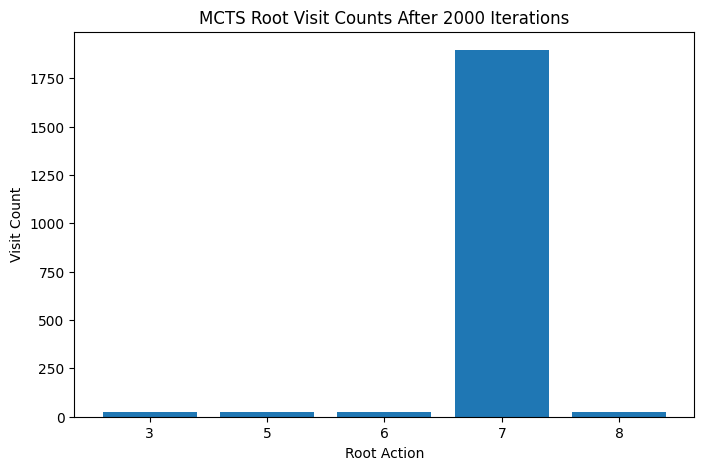

In [15]:
actions = sorted(
    searched_root.children
)

visits = [
    searched_root.children[
        action
    ].visits
    for action
    in actions
]

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    [str(action) for action in actions],
    visits,
)

plt.xlabel("Root Action")
plt.ylabel("Visit Count")
plt.title(
    "MCTS Root Visit Counts After 2000 Iterations"
)
plt.show()

# 13. Inspect UCT Numerically

To see Selection directly, the next cell calculates the current UCT score for every root child.

The formula is

$$
\text{UCT}(s,a)
=
\bar Q(s,a)
+
c
\sqrt{
\frac{\ln N(s)}
{N(s,a)}
}.
$$

In [16]:
print(
    "Root visits:",
    searched_root.visits,
)

print()

for action in sorted(
    searched_root.children
):
    child = (
        searched_root.children[
            action
        ]
    )

    exploitation = (
        child.mean_value
    )

    exploration = (
        math.sqrt(2)
        * math.sqrt(
            math.log(
                searched_root.visits
            )
            / child.visits
        )
    )

    uct = (
        exploitation
        + exploration
    )

    print(
        f"Action {action}: "
        f"Q={exploitation:.4f}, "
        f"exploration={exploration:.4f}, "
        f"UCT={uct:.4f}"
    )

Root visits: 2000

Action 3: Q=-0.6923, exploration=0.7646, UCT=0.0723
Action 5: Q=-0.6667, exploration=0.7504, UCT=0.0837
Action 6: Q=-0.6667, exploration=0.7504, UCT=0.0837
Action 7: Q=0.0011, exploration=0.0895, UCT=0.0906
Action 8: Q=-0.7083, exploration=0.7959, UCT=0.0875


UCT is used **during** search to decide which branch should be explored next.

The final move does not have to be the child with the largest current UCT score. This implementation selects the final root move using the largest visit count after the search budget is exhausted.

# 14. How Search Statistics Change with More Simulations

MCTS is an anytime planning algorithm. It can return an action after a small search budget, but more simulations usually provide stronger estimates.

The next cell runs the same position with several search budgets and records the root statistics generated by the code.

In [17]:
search_budgets = [
    25,
    100,
    500,
    2000,
]

budget_results = {}

for budget in search_budgets:
    action, root = run_mcts(
        demo_board,
        demo_player,
        iterations=budget,
        seed=42,
    )

    budget_results[
        budget
    ] = {
        "selected_action": action,
        "root": root,
    }

    print(
        "=" * 60
    )

    print(
        "Iterations:",
        budget,
    )

    print(
        "Selected action:",
        action,
    )

    for root_action in sorted(
        root.children
    ):
        child = (
            root.children[
                root_action
            ]
        )

        print(
            f"  action={root_action}, "
            f"visits={child.visits}, "
            f"mean={child.mean_value:.3f}"
        )

Iterations: 25
Selected action: 7
  action=3, visits=2, mean=-1.000
  action=5, visits=6, mean=0.167
  action=6, visits=6, mean=0.167
  action=7, visits=8, mean=0.250
  action=8, visits=3, mean=-0.333
Iterations: 100
Selected action: 7
  action=3, visits=10, mean=-0.500
  action=5, visits=13, mean=-0.385
  action=6, visits=13, mean=-0.385
  action=7, visits=54, mean=0.056
  action=8, visits=10, mean=-0.500


Iterations: 500
Selected action: 7
  action=3, visits=18, mean=-0.667
  action=5, visits=22, mean=-0.591
  action=6, visits=22, mean=-0.591
  action=7, visits=420, mean=0.000
  action=8, visits=18, mean=-0.667


Iterations: 2000
Selected action: 7
  action=3, visits=26, mean=-0.692
  action=5, visits=27, mean=-0.667
  action=6, visits=27, mean=-0.667
  action=7, visits=1896, mean=0.001
  action=8, visits=24, mean=-0.708


This output shows how the tree becomes increasingly concentrated as the search budget grows.

## 15. Visit-share convergence for the tactical move

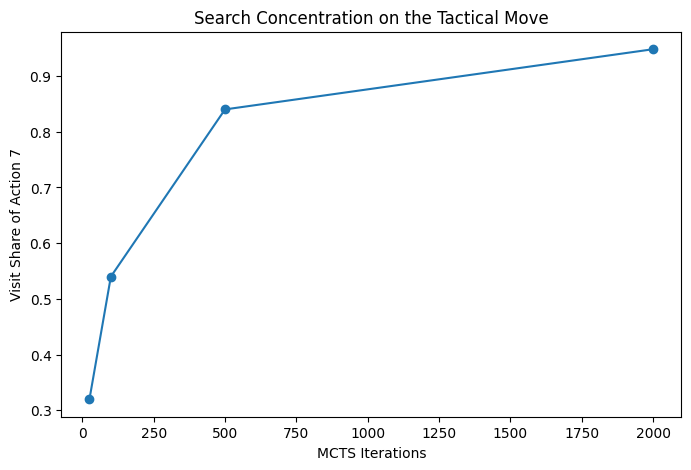

In [18]:
tactical_action = 7

visit_shares = []

for budget in search_budgets:
    root = (
        budget_results[
            budget
        ]["root"]
    )

    share = (
        root.children[
            tactical_action
        ].visits
        / root.visits
    )

    visit_shares.append(
        share
    )

plt.figure(
    figsize=(8, 5)
)

plt.plot(
    search_budgets,
    visit_shares,
    marker="o",
)

plt.xlabel(
    "MCTS Iterations"
)

plt.ylabel(
    "Visit Share of Action 7"
)

plt.title(
    "Search Concentration on the Tactical Move"
)

plt.show()

# 16. Use MCTS as a Tic-Tac-Toe Agent

At every turn, the agent can run a fresh MCTS search from the current board and select the action with the largest root visit count.

In [19]:
def choose_mcts_action(
    board,
    player,
    iterations=300,
    seed=0,
):
    action, _ = run_mcts(
        board,
        player,
        iterations=iterations,
        seed=seed,
    )

    return action

## 17. Play one complete MCTS-versus-random game

In [20]:
def play_one_game(
    mcts_player=X,
    mcts_iterations=300,
    seed=100,
    verbose=False,
):
    rng = random.Random(seed)

    board = initial_board
    player = X
    move_number = 0

    if verbose:
        print(
            render_board(
                board,
                show_indices=True,
            )
        )

        print()

    while winner(board) is None:
        move_number += 1

        if player == mcts_player:
            action = (
                choose_mcts_action(
                    board,
                    player,
                    iterations=(
                        mcts_iterations
                    ),
                    seed=(
                        seed
                        + 1000
                        * move_number
                    ),
                )
            )

            controller = "MCTS"

        else:
            action = rng.choice(
                legal_actions(board)
            )

            controller = "Random"

        board = apply_action(
            board,
            action,
            player,
        )

        if verbose:
            print(
                f"Move {move_number}: "
                f"{player_symbol(player)} "
                f"({controller}) "
                f"chooses {action}"
            )

            print(
                render_board(
                    board,
                    show_indices=True,
                )
            )

            print()

        player = -player

    return (
        winner(board),
        board,
    )


single_outcome, _ = play_one_game(
    mcts_player=X,
    mcts_iterations=300,
    seed=100,
    verbose=True,
)

print(
    "Final result:",
    (
        "Draw"
        if single_outcome == 0
        else (
            f"{player_symbol(single_outcome)} wins"
        )
    ),
)

0 | 1 | 2
---------
3 | 4 | 5
---------
6 | 7 | 8

Move 1: X (MCTS) chooses 0
X | 1 | 2
---------
3 | 4 | 5
---------
6 | 7 | 8

Move 2: O (Random) chooses 3
X | 1 | 2
---------
O | 4 | 5
---------
6 | 7 | 8



Move 3: X (MCTS) chooses 2
X | 1 | X
---------
O | 4 | 5
---------
6 | 7 | 8

Move 4: O (Random) chooses 6
X | 1 | X
---------
O | 4 | 5
---------
O | 7 | 8

Move 5: X (MCTS) chooses 1
X | X | X
---------
O | 4 | 5
---------
O | 7 | 8

Final result: X wins


# 18. Evaluate MCTS Against a Random Player

The following experiment evaluates the same search procedure across multiple games.

Two cases are tested:

1. MCTS plays first as `X`.
2. MCTS plays second as `O`.

The result is empirical because both MCTS rollouts and the opponent use random sampling.

In [21]:
def evaluate_mcts_vs_random(
    mcts_player,
    games=100,
    mcts_iterations=300,
    seed=123,
):
    wins = 0
    draws = 0
    losses = 0

    for game in range(games):
        outcome, _ = play_one_game(
            mcts_player=mcts_player,
            mcts_iterations=(
                mcts_iterations
            ),
            seed=(
                seed
                + game * 37
            ),
            verbose=False,
        )

        if outcome == mcts_player:
            wins += 1

        elif outcome == 0:
            draws += 1

        else:
            losses += 1

    return {
        "games": games,
        "wins": wins,
        "draws": draws,
        "losses": losses,
        "win_rate": wins / games,
        "draw_rate": draws / games,
        "loss_rate": losses / games,
    }


mcts_as_x = evaluate_mcts_vs_random(
    mcts_player=X,
    games=100,
    mcts_iterations=300,
    seed=123,
)

mcts_as_o = evaluate_mcts_vs_random(
    mcts_player=O,
    games=100,
    mcts_iterations=300,
    seed=456,
)

print("MCTS as X:")
print(mcts_as_x)

print("\nMCTS as O:")
print(mcts_as_o)

MCTS as X:
{'games': 100, 'wins': 99, 'draws': 1, 'losses': 0, 'win_rate': 0.99, 'draw_rate': 0.01, 'loss_rate': 0.0}

MCTS as O:
{'games': 100, 'wins': 92, 'draws': 8, 'losses': 0, 'win_rate': 0.92, 'draw_rate': 0.08, 'loss_rate': 0.0}


The evaluation does not represent a universal MCTS performance guarantee. It reports the results produced by this implementation, search budget, rollout policy, random seeds, and random opponent.

## 19. Performance visualization

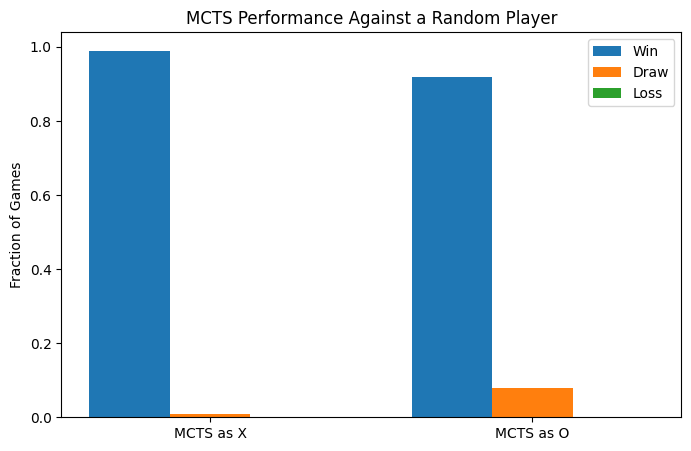

In [22]:
labels = [
    "MCTS as X",
    "MCTS as O",
]

win_rates = [
    mcts_as_x["win_rate"],
    mcts_as_o["win_rate"],
]

draw_rates = [
    mcts_as_x["draw_rate"],
    mcts_as_o["draw_rate"],
]

loss_rates = [
    mcts_as_x["loss_rate"],
    mcts_as_o["loss_rate"],
]

x = np.arange(
    len(labels)
)

width = 0.25

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    x - width,
    win_rates,
    width,
    label="Win",
)

plt.bar(
    x,
    draw_rates,
    width,
    label="Draw",
)

plt.bar(
    x + width,
    loss_rates,
    width,
    label="Loss",
)

plt.xticks(
    x,
    labels,
)

plt.ylabel(
    "Fraction of Games"
)

plt.title(
    "MCTS Performance Against a Random Player"
)

plt.legend()
plt.show()

# 20. Why MCTS Is a Planning Method

MCTS assumes that the consequences of actions can be simulated.

For Tic-Tac-Toe, the transition model is known exactly:

$$
(s,a)
\rightarrow
s'.
$$

The search repeatedly uses that model to imagine possible futures before selecting the real action.

That is planning.

MCTS differs from Dynamic Programming methods such as Value Iteration.

### Value Iteration

Value Iteration systematically applies Bellman backups across the state space:

$$
V_{k+1}(s)
=
\max_a
\sum_{s'}
P(s'|s,a)
\left[
R(s,a,s')
+
\gamma V_k(s')
\right].
$$

### MCTS

MCTS does not sweep through every state.

Instead, it selectively builds a search tree around the current decision:

$$
\text{Selection}
\rightarrow
\text{Expansion}
\rightarrow
\text{Simulation}
\rightarrow
\text{Backpropagation}.
$$

This becomes useful when exhaustively evaluating the complete state space is expensive.

# 21. MCTS Algorithm Summary

```text
Input:
    current state s
    simulation budget B

Create root node from s

for iteration = 1 to B:

    1. Selection
       Starting at root,
       repeatedly select the child
       with maximum UCT while the
       node is fully expanded.

    2. Expansion
       If the selected node has an
       untried legal action, create
       one new child.

    3. Simulation
       Roll out from the new node
       until a terminal state is reached.

    4. Backpropagation
       Propagate the terminal result
       through every node on the path:
           N <- N + 1
           W <- W + G
           Qbar <- W / N

Final action:
    choose the root child
    with the largest visit count.
```

The key equations are:

### Mean return

$$
\bar Q(s,a)
=
\frac{W(s,a)}{N(s,a)}.
$$

### UCT

$$
\text{UCT}(s,a)
=
\bar Q(s,a)
+
c
\sqrt{
\frac{\ln N(s)}
{N(s,a)}
}.
$$

### Selection during search

$$
a_{\text{UCT}}
=
\arg\max_a
\text{UCT}(s,a).
$$

### Final root action

$$
a^*
=
\arg\max_a
N(s,a).
$$

# 22. Key Observations

- MCTS is a **search-based planning algorithm**.
- It does not require a neural network.
- It does not perform conventional offline training.
- The search tree accumulates $N$, $W$, and $\bar Q$ statistics.
- Selection balances exploitation and exploration through UCT.
- Expansion adds previously unexplored actions.
- Simulation estimates future outcomes through rollouts.
- Backpropagation updates the search evidence.
- Increasing the search budget provides more simulations and generally stronger estimates.
- The final decision is based on the statistics accumulated at the root.
- Tic-Tac-Toe is small enough to make every stage visible, while the same MCTS idea can be applied to much larger search problems.